In [14]:
week = 12
function = 4

In [15]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [16]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

In [17]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)
# print(f"\tloaded original data set...")

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
print("\tsetting values below numerical precision to zero")
df.loc[df["Y1"].abs() < 1e-6, "Y1"] = 0

print("\tscaling output variable")
Q3 = df["Y1"].quantile(0.75)
df["promising"] = (df["Y1"] >= Q3).astype(int)

print("\textracting input variables")
input_cols = data_loading.get_X_cols(df)

print("\tfinding points within threshold of current max")
df_fitting = data_augmentation.extract_distance_from_max(df, "Y1", input_cols, 12)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

df_fitting.loc[:, "YScaled"] = y_scaler.fit_transform(df_fitting[["Y1"]])
df_fitting.loc[:, input_cols] = x_scaler.fit_transform(df_fitting[input_cols])

print("\tseparating iputs and outputs for fitting")
X = df_fitting[input_cols].to_numpy(dtype=np.float32)
y = df_fitting["YScaled"].to_numpy(dtype=np.float32).reshape(-1,1)

print(f"\n Current Max Value: {df['Y1'].max()}")

Requested function 4 in week 12

Data Loading
	Loaded initial data: function_4
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk11.csv
		4: new_data_point_wk2.csv
		5: new_data_point_wk3.csv
		6: new_data_point_wk4.csv
		7: new_data_point_wk5.csv
		8: new_data_point_wk6.csv
		9: new_data_point_wk7.csv
		10: new_data_point_wk8.csv
		11: new_data_point_wk9.csv
	Added 11 new data points.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_12\function_4...

Data Preprocessing
	setting values below numerical precision to zero
	scaling output variable
	extracting input variables
	finding points within threshold of current max
	separating iputs and outputs for fitting

 Current Max Value: -3.744235519


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================================
# Convert data
# =====================================================

x_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

n_features = x_train.shape[1]

In [19]:
# =====================================================
# Forward pass
# =====================================================

def forward_pass(x):

    # Add bias column
    bias = tf.ones((tf.shape(x)[0], 1))
    x = tf.concat([x, bias], axis=1)

    hidden = tf.matmul(x, W1)
    hidden = tf.nn.relu(hidden)

    output = tf.matmul(hidden, W2)

    return output

# =====================================================
# Training step
# =====================================================

@tf.function
def train_step(x, y):

    with tf.GradientTape() as tape:

        y_pred = forward_pass(x)
        loss = loss_fn(y, y_pred)

    gradients = tape.gradient(loss,[W1, W2])

    optimizer.apply_gradients(zip(gradients, [W1, W2]))

    return loss

In [ ]:
#hyperparamters
n_hidden = 2
epochs = 5000
lr = 0.04

In [21]:

# =====================================================
# Loss / Optimizer
# =====================================================

loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.SGD(learning_rate=lr)

# =====================================================
# Initialize weights (He initialization)
# =====================================================

W1 = tf.Variable(tf.random.normal(shape=(n_features + 1, n_hidden),stddev=np.sqrt(2 / n_features)))
W2 = tf.Variable(tf.random.normal(shape=(n_hidden, 1),stddev=np.sqrt(2 / n_hidden)))

Epoch 0: Loss = 11.266664
Epoch 500: Loss = 0.657020
Epoch 1000: Loss = 0.653138
Epoch 1500: Loss = 0.651257
Epoch 2000: Loss = 0.650013
Epoch 2500: Loss = 0.649419
Epoch 3000: Loss = 0.649112
Epoch 3500: Loss = 0.648968
Epoch 4000: Loss = 0.648908
Epoch 4500: Loss = 0.648886
Epoch 5000: Loss = 0.648878
Epoch 5500: Loss = 0.648875
Epoch 6000: Loss = 0.648874
Epoch 6500: Loss = 0.648874
Epoch 7000: Loss = 0.648874
Epoch 7500: Loss = 0.648873
Epoch 8000: Loss = 0.648873
Epoch 8500: Loss = 0.648873
Epoch 9000: Loss = 0.648873
Epoch 9500: Loss = 0.648873
Epoch 10000: Loss = 0.648873
Epoch 10500: Loss = 0.648873
Epoch 11000: Loss = 0.648873
Epoch 11500: Loss = 0.648873
Epoch 12000: Loss = 0.648873
Epoch 12500: Loss = 0.648873
Epoch 13000: Loss = 0.648873
Epoch 13500: Loss = 0.648873
Epoch 14000: Loss = 0.648873
Epoch 14500: Loss = 0.648873
Epoch 15000: Loss = 0.648873
Epoch 15500: Loss = 0.648873
Epoch 16000: Loss = 0.648873
Epoch 16500: Loss = 0.648873
Epoch 17000: Loss = 0.648873
Epoch 17

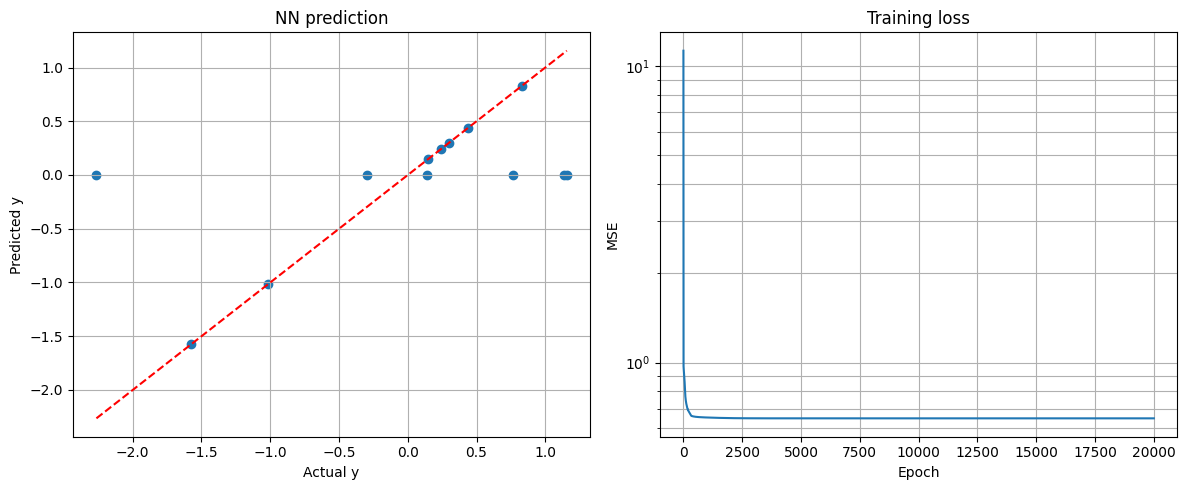

In [22]:

loss_history = []

for epoch in range(epochs):

    loss = train_step(x_train, y_train)

    loss_history.append(loss.numpy())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.6f}")

y_pred = forward_pass(X).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 5))

ax1.scatter(y.flatten(),y_pred.flatten())

lims = [min(y.min(), y_pred.min()),max(y.max(), y_pred.max())]

ax1.plot(lims,lims,"r--")

ax1.set_xlabel("Actual y")
ax1.set_ylabel("Predicted y")
ax1.set_title("NN prediction")
ax1.grid(True)

# ---------------------
# Loss curve (log scale)
# ---------------------

ax2.plot(loss_history)

ax2.set_yscale("log")      # logarithmic y-axis

ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE")
ax2.set_title("Training loss")
ax2.grid(True, which="both")

plt.tight_layout()
plt.show()

In [23]:
print(f"Calaculating Convex Hull around chosen data set...")
hull, points_hull = data_augmentation.compute_convex_hull(df_fitting[input_cols])
internal_points = data_augmentation.seed_convex_hull(points_hull, hull)

y_test = forward_pass(internal_points).numpy()
best_index = np.argmax(y_test)

x_max = internal_points[best_index]
y_max = y_test[best_index]

# undo scaling
x_max_original = x_scaler.inverse_transform(
    x_max.reshape(1, -1)
)

y_max_original = y_scaler.inverse_transform(
    y_max.reshape(1, -1)
)

print("Maximum location:")
print(x_max_original)

print("Maximum value:")
print(y_max_original,df["Y1"].max())

Calaculating Convex Hull around chosen data set...
Maximum location:
[[0.46070622 0.35321456 0.33431874 0.57183308]]
Maximum value:
[[-4.76846]] -3.744235519


(<Figure size 1000x250 with 4 Axes>,
 array([[<Axes: xlabel='X1', ylabel='YScaled'>, <Axes: xlabel='X2'>,
         <Axes: xlabel='X3'>, <Axes: xlabel='X4'>]], dtype=object))

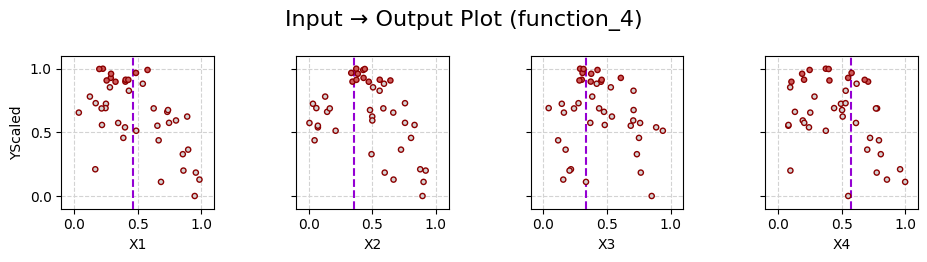

In [24]:
best_point_dict = {col: val for col, val in zip(input_cols, x_max_original[0])}

X = df[input_cols].to_numpy()

df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])
Y = df["YScaled"].to_numpy()
Y = np.asarray(Y).reshape(-1, 1)

try:
    Z = df["promising"].to_numpy().reshape(-1, 1)
except:
    Z = np.zeros(len(Y)) 

data_plotting.domain_io_plot(data_folder_name, results_dir, input_cols, ["YScaled"], X, Y, Z, next_point=best_point_dict)

In [25]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.460706-0.353215-0.334319-0.571833


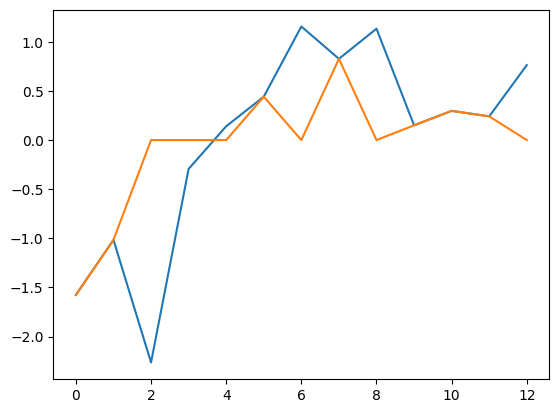

In [26]:
plt.plot(range(len(y)),y)
plt.plot(range(len(y)),y_pred)